<a href="https://colab.research.google.com/github/ngocanh2103iot-cloud/dsa/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_kitchen2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
!pip install librosa

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
chopping_path = "/content/drive/MyDrive/training/chopping"
door_path="/content/drive/MyDrive/training/door"
frying_path="/content/drive/MyDrive/training/frying"
gas_path="/content/drive/MyDrive/training/gas"
water_path="/content/drive/MyDrive/training/water"
nothing_path="/content/drive/MyDrive/training/nothing"

In [ ]:
def load_audio_files(path, label):
    audio_files = []
    labels = []
    for filename in os.listdir(path):
        if filename.endswith('.wav'):
            file_path = os.path.join(path, filename)
            audio, sample_rate = librosa.load(file_path, sr=16000)
            audio_files.append(audio)
            labels.append(label)
    return audio_files, labels, sample_rate

chopping_audio, chopping_labels, sample_rate = load_audio_files(chopping_path, label=0)
door_audio, door_labels, sample_rate = load_audio_files(door_path, label=1)
frying_audio, frying_labels, sample_rate = load_audio_files(frying_path, label=2)
gas_audio, gas_labels, sample_rate = load_audio_files(gas_path, label=3)
water_audio, water_labels, sample_rate = load_audio_files(water_path, label=4)
nothing_audio, nothing_labels, sample_rate = load_audio_files(nothing_path, label=5)

In [ ]:
import numpy as np
from scipy.fftpack import dct

def extract_mfccs(audio, sample_rate, n_mfcc=13, n_mels=40, n_fft=2048, hop_length=512):
    pre_emphasis = 0.97
    emphasized_signal = np.append(audio[0], audio[1:] - pre_emphasis * audio[:-1])

    frame_length, frame_step = n_fft, hop_length
    signal_length = len(emphasized_signal)
    num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))
    pad_signal_length = num_frames * frame_step + frame_length
    pad_signal = np.append(emphasized_signal, np.zeros((pad_signal_length - signal_length)))

    indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    frames = pad_signal[indices.astype(np.int32, copy=False)]

    frames *= np.hamming(frame_length)

    mag_frames = np.absolute(np.fft.rfft(frames, n_fft))
    pow_frames = ((1.0 / n_fft) * (mag_frames ** 2))

    low_freq_mel = 0
    high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700))
    mel_points = np.linspace(low_freq_mel, high_freq_mel, n_mels + 2)
    hz_points = (700 * (10**(mel_points / 2595) - 1))
    bin = np.floor((n_fft + 1) * hz_points / sample_rate)

    fbank = np.zeros((n_mels, int(np.floor(n_fft / 2 + 1))))
    for m in range(1, n_mels + 1):
        for k in range(int(bin[m-1]), int(bin[m])): fbank[m-1, k] = (k - bin[m-1]) / (bin[m] - bin[m-1])
        for k in range(int(bin[m]), int(bin[m+1])): fbank[m-1, k] = (bin[m+1] - k) / (bin[m+1] - bin[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    filter_banks = 20 * np.log10(filter_banks) # dB scale

    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, :n_mfcc]
    return np.mean(mfcc, axis=0)

In [ ]:
def augment_audio(audio, sample_rate, noise_factor=0.005, shift_max=0.2):
    # Time Shifting
    shift = np.random.randint(int(sample_rate * shift_max))
    augmented_audio = np.roll(audio, shift)

    # Adding Noise
    noise = np.random.randn(len(augmented_audio))
    augmented_audio = augmented_audio + noise_factor * noise

    return augmented_audio

In [ ]:
n_mfcc = 13
mfcc_labels = [f'MFCC_{i+1}' for i in range(n_mfcc)]
feature_names = mfcc_labels

feature_names

['MFCC_1',
 'MFCC_2',
 'MFCC_3',
 'MFCC_4',
 'MFCC_5',
 'MFCC_6',
 'MFCC_7',
 'MFCC_8',
 'MFCC_9',
 'MFCC_10',
 'MFCC_11',
 'MFCC_12',
 'MFCC_13']

In [ ]:
from scipy.stats.distributions import f
def extract_features(audio_data, sample_rate):
    features = []
    for audio in audio_data:
        mfccs = extract_mfccs(audio, sample_rate)
        all_features = np.concatenate([mfccs])
        features.append(all_features)
    return np.array(features)

chopping_features = extract_features(chopping_audio, sample_rate)
door_features = extract_features(door_audio, sample_rate)
frying_features = extract_features(frying_audio, sample_rate)
gas_features = extract_features(gas_audio, sample_rate)
water_features = extract_features(water_audio, sample_rate)
nothing_features = extract_features(nothing_audio, sample_rate)


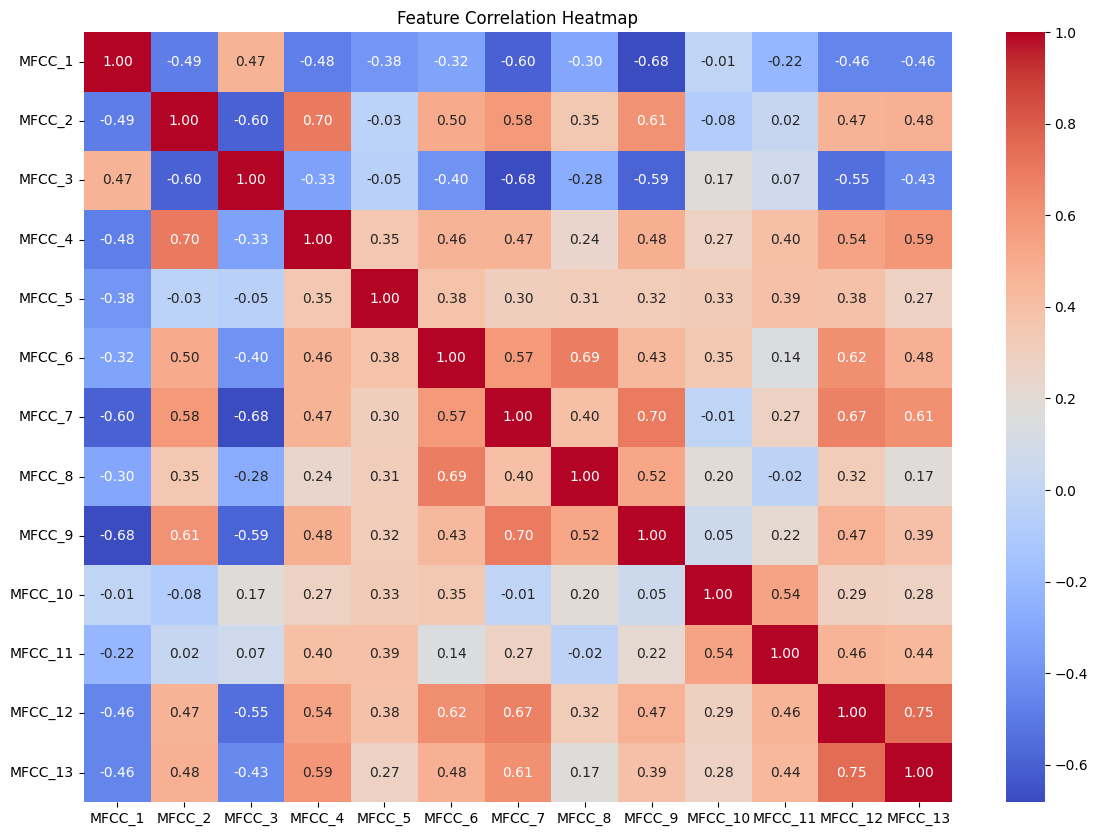

In [ ]:
import seaborn as sns

features = np.concatenate((chopping_features, door_features, frying_features, gas_features, water_features, nothing_features))

corr_matrix = np.corrcoef(features.T)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', xticklabels=feature_names, yticklabels=feature_names)
plt.title('Feature Correlation Heatmap')
plt.show()

/tmp/ipykernel_8174/4051831764.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels_for_plot)
/tmp/ipykernel_8174/4051831764.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels_for_plot)
/tmp/ipykernel_8174/4051831764.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels_for_plot)
/tmp/ipykernel_8174/4051831764.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_t

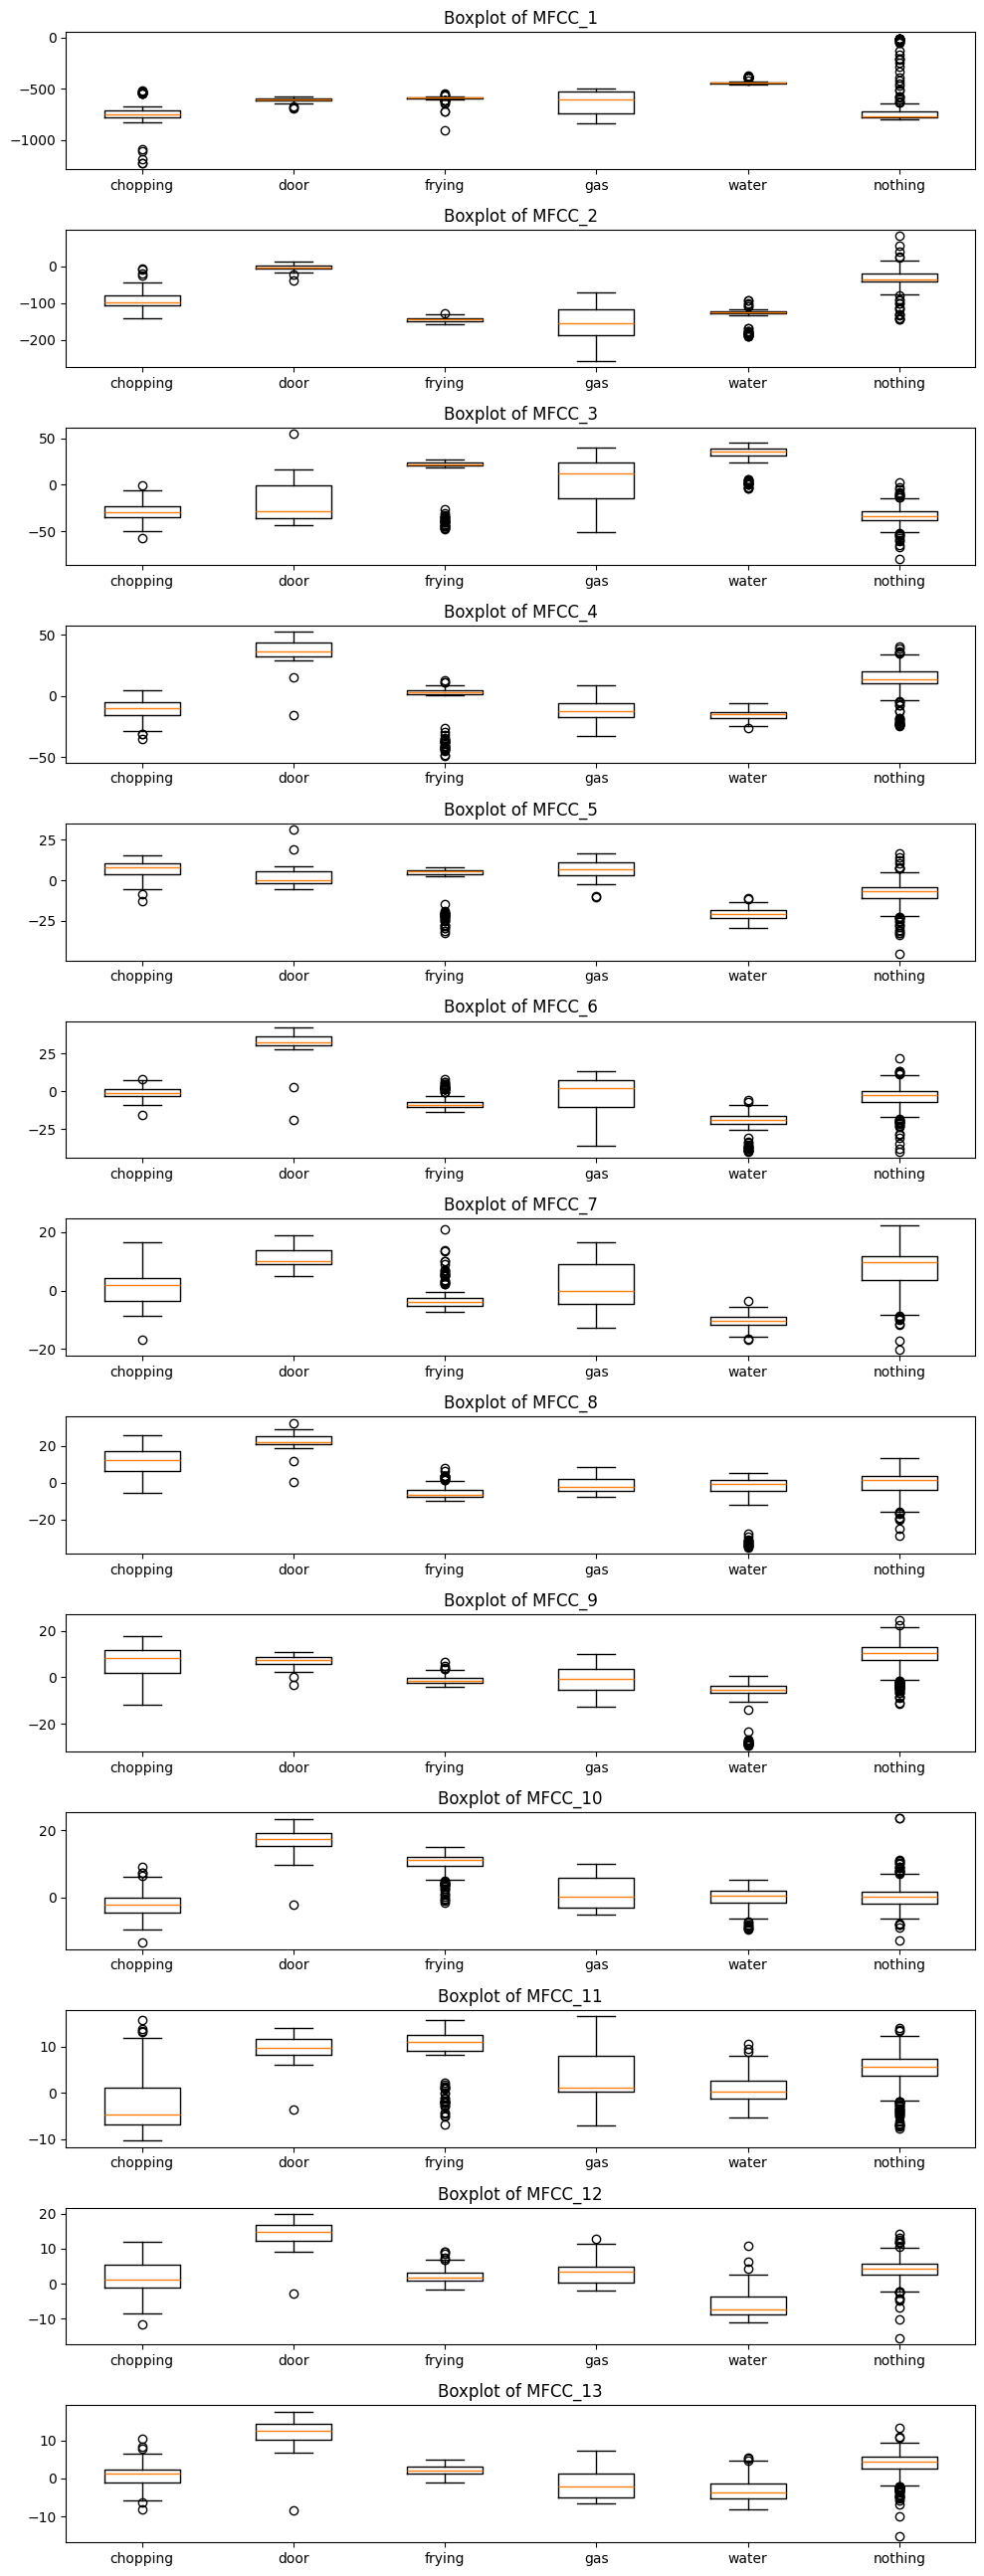

In [ ]:
import matplotlib.pyplot as plt

def plot_feature_boxplots(chopping_features, door_features, frying_features, gas_features, water_features, nothing_features, feature_names):
    number_of_features = nothing_features.shape[1]
    fig = plt.figure(figsize=(10, 2 * number_of_features))

    for i in range(number_of_features):
        ax = fig.add_subplot(number_of_features, 1, i + 1)
        data_to_plot = [
            chopping_features[:, i],
            door_features[:, i],
            frying_features[:, i],
            gas_features[:, i],
            water_features[:, i],
            nothing_features[:, i]
        ]
        labels_for_plot = ['chopping', 'door', 'frying', 'gas', 'water', 'nothing']
        ax.boxplot(data_to_plot, labels=labels_for_plot)
        ax.set_title(f'Boxplot of {feature_names[i]}')

    plt.tight_layout()
    plt.show()

plot_feature_boxplots(chopping_features, door_features, frying_features, gas_features, water_features, nothing_features, feature_names)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

all_labels = chopping_labels + door_labels + frying_labels + gas_labels + water_labels + nothing_labels
labels_array = np.array(all_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels_array,
    test_size=0.3,
    random_state=42,
    stratify=labels_array
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_combined_test = np.concatenate((X_val_scaled, X_test_scaled))
y_combined_test = np.concatenate((y_val, y_test))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def build_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=16, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


cnn_summary = build_cnn_model(input_shape=(23, 1))
cnn_summary.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 23, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 11, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,326 (48.15 KB)

 Trainable params: 12,326 (48.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def train_cnn_model(X_train_scaled, y_train, X_val_scaled, y_val):
    X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
    X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

    input_shape = (X_train_reshaped.shape[1], 1)

    cnn_model = build_cnn_model(input_shape)

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = cnn_model.fit(
        X_train_reshaped, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val_reshaped, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return cnn_model, history

print("Defined train_cnn_model function for CNN training and plotting.")

Defined train_cnn_model function for CNN training and plotting.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_cnn_model(cnn_model, X_combined_test, y_combined_test):
    X_test_reshaped = X_combined_test.reshape(X_combined_test.shape[0], X_combined_test.shape[1], 1)

    y_pred_probs = cnn_model.predict(X_test_reshaped)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_combined_test, y_pred)
    precision = precision_score(y_combined_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_combined_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_combined_test, y_pred, average='weighted', zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")

    cm = confusion_matrix(y_combined_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Chopping', 'Door', 'Frying', 'Gas', 'Water', 'Nothing'], yticklabels=['Chopping', 'Door', 'Frying', 'Gas', 'Water', 'Nothing'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for CNN Model')
    plt.show()

print("Defined evaluate_cnn_model function for CNN evaluation and plotting.")

Defined evaluate_cnn_model function for CNN evaluation and plotting.


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.4094 - loss: 1.6466 - val_accuracy: 0.5500 - val_loss: 1.4676
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6055 - loss: 1.3369 - val_accuracy: 0.6500 - val_loss: 1.2058
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7079 - loss: 1.0815 - val_accuracy: 0.7100 - val_loss: 0.9794
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7676 - loss: 0.8730 - val_accuracy: 0.7700 - val_loss: 0.7653
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7868 - loss: 0.6859 - val_accuracy: 0.7800 - val_loss: 0.6372
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8657 - loss: 0.5133 - val_accuracy: 0.8400 - val_loss: 0.4482
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8934 - loss: 0.3875 - val_accuracy: 0.8600 - val_loss: 0.3737
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9104 - loss: 0.3211 - val_accuracy: 0.9

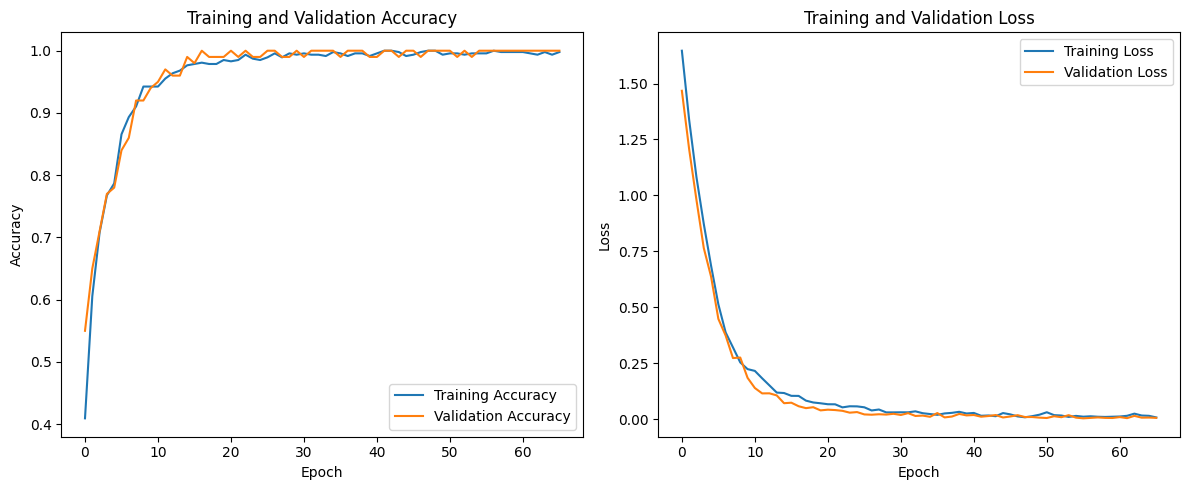

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1 Score (weighted): 1.0000


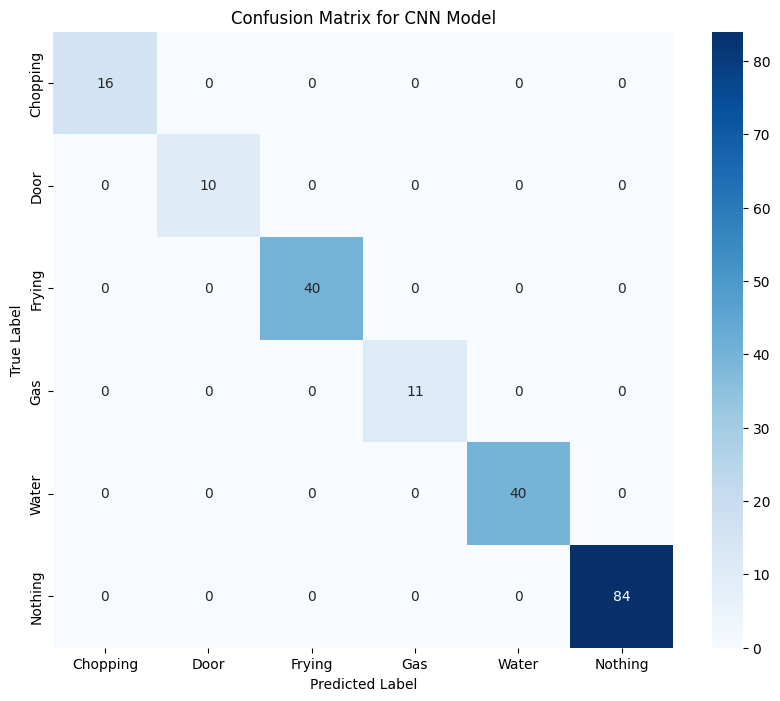

In [ ]:
cnn_model, history = train_cnn_model(X_train_scaled, y_train, X_val_scaled, y_val)
evaluate_cnn_model(cnn_model, X_combined_test, y_combined_test)

In [ ]:
def extract_mfccs_2d(audio, sample_rate, n_mfcc=13, n_mels=40, n_fft=2048, hop_length=512):
    pre_emphasis = 0.97
    emphasized_signal = np.append(audio[0], audio[1:] - pre_emphasis * audio[:-1])
    frame_length, frame_step = n_fft, hop_length
    signal_length = len(emphasized_signal)
    num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))
    pad_signal_length = num_frames * frame_step + frame_length
    pad_signal = np.append(emphasized_signal, np.zeros((pad_signal_length - signal_length)))
    indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    frames = pad_signal[indices.astype(np.int32, copy=False)]
    frames *= np.hamming(frame_length)
    mag_frames = np.absolute(np.fft.rfft(frames, n_fft))
    pow_frames = ((1.0 / n_fft) * (mag_frames ** 2))
    low_freq_mel = 0
    high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700))
    mel_points = np.linspace(low_freq_mel, high_freq_mel, n_mels + 2)
    hz_points = (700 * (10**(mel_points / 2595) - 1))
    bin = np.floor((n_fft + 1) * hz_points / sample_rate)
    fbank = np.zeros((n_mels, int(np.floor(n_fft / 2 + 1))))
    for m in range(1, n_mels + 1):
        for k in range(int(bin[m-1]), int(bin[m])): fbank[m-1, k] = (k - bin[m-1]) / (bin[m] - bin[m-1])
        for k in range(int(bin[m]), int(bin[m+1])): fbank[m-1, k] = (bin[m+1] - k) / (bin[m+1] - bin[m])
    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    filter_banks = 20 * np.log10(filter_banks)
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, :n_mfcc]
    max_len = 400
    if mfcc.shape[0] < max_len:
        mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]
    return mfcc

def extract_features_2d(audio_data, sample_rate):
    features = []
    for audio in audio_data:
        mfccs = extract_mfccs_2d(audio, sample_rate)
        features.append(mfccs)
    return np.array(features)

chopping_features_2d = extract_features_2d(chopping_audio, sample_rate)
door_features_2d = extract_features_2d(door_audio, sample_rate)
frying_features_2d = extract_features_2d(frying_audio, sample_rate)
gas_features_2d = extract_features_2d(gas_audio, sample_rate)
water_features_2d = extract_features_2d(water_audio, sample_rate)
nothing_features_2d = extract_features_2d(nothing_audio, sample_rate)

X_2d = np.concatenate((chopping_features_2d, door_features_2d, frying_features_2d, gas_features_2d, water_features_2d, nothing_features_2d))
Y_2d = np.array(chopping_labels + door_labels + frying_labels + gas_labels + water_labels + nothing_labels)
print(f"New dataset shape: {X_2d.shape}")

Extracting 2D MFCC matrices using custom logic...
New dataset shape: (670, 400, 13)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

def build_cnn2d_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(16, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(6, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return mode

X_train, X_test, y_train, y_test = train_test_split(X_2d, Y_2d, test_size=0.2, stratify=Y_2d, random_state=42)
X_train_reshaped = X_train[..., np.newaxis]
X_test_reshaped = X_test[..., np.newaxis]

cnn2d_summary = build_cnn2d_model(input_shape=(400, 13, 1))
cnn2d_summary.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 400, 13, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 200, 6, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 200, 6, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 100, 3, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100, 3, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       614,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,654 (2.36 MB)

 Trainable params: 619,654 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
model_2d = build_cnn2d_model(input_shape=(400, 13, 1))

# Configure early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Starting training for the 2D Conv model...")
history_2d = model_2d.fit(
    X_train_reshaped, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
loss, acc = model_2d.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc:.4f}")

Starting training for the 2D Conv model...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.3481 - loss: 10.7486 - val_accuracy: 0.1667 - val_loss: 1.6008
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.3294 - loss: 1.6231 - val_accuracy: 0.5926 - val_loss: 1.0179
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.5140 - loss: 1.3220 - val_accuracy: 0.6852 - val_loss: 0.7131
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5631 - loss: 1.0853 - val_accuracy: 0.8333 - val_loss: 0.6016
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6075 - loss: 0.9274 - val_accuracy: 0.8148 - val_loss: 0.5100
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.6636 - loss: 0.8496 - val_accuracy: 0.8889 - val_loss: 0.4278
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.6706 - loss: 0.7649 - val_accuracy: 0.8148 - val_loss: 0.4297
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accura

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


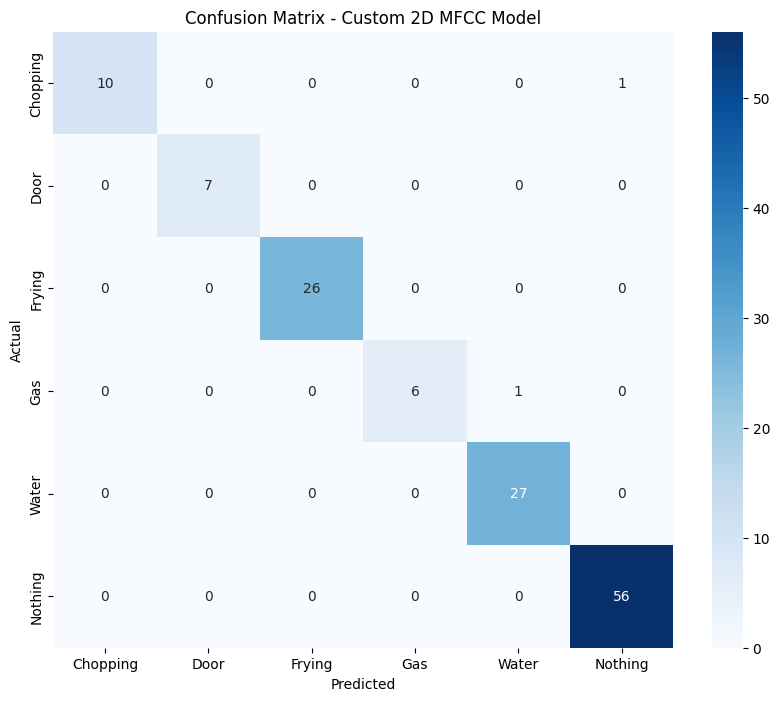

              precision    recall  f1-score   support

    Chopping       1.00      0.91      0.95        11
        Door       1.00      1.00      1.00         7
      Frying       1.00      1.00      1.00        26
         Gas       1.00      0.86      0.92         7
       Water       0.96      1.00      0.98        27
     Nothing       0.98      1.00      0.99        56

    accuracy                           0.99       134
   macro avg       0.99      0.96      0.97       134
weighted avg       0.99      0.99      0.98       134



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.show()

y_pred_2d = np.argmax(model_2d.predict(X_test_reshaped), axis=1)
cm_2d = confusion_matrix(y_test, y_pred_2d)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Chopping', 'Door', 'Frying', 'Gas', 'Water', 'Nothing'],
            yticklabels=['Chopping', 'Door', 'Frying', 'Gas', 'Water', 'Nothing'])
plt.title('Confusion Matrix - Custom 2D MFCC Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred_2d, target_names=['Chopping', 'Door', 'Frying', 'Gas', 'Water', 'Nothing']))